In [1]:
import numpy as np
import torch
from torch import nn
import tqdm
import seaborn as sns

In [2]:
import torchvision
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
import time

106
12
40
Feature batch shape: torch.Size([512, 1, 28, 28])
Labels batch shape: torch.Size([512])


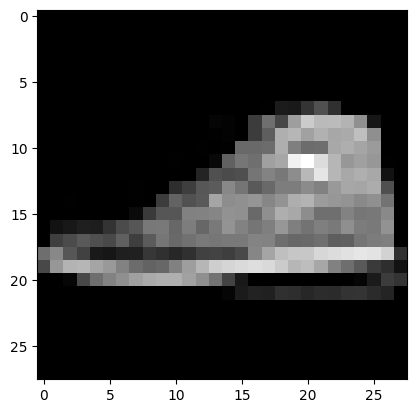

Label: 9
Feature batch shape: torch.Size([512, 1, 28, 28])
Labels batch shape: torch.Size([512])


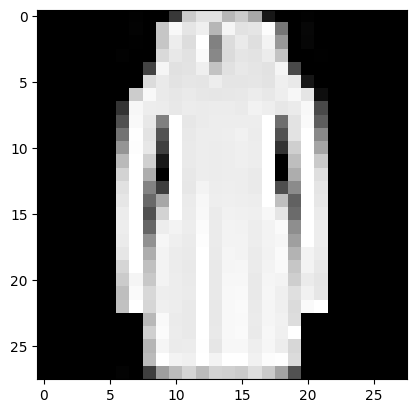

Label: 3
Feature batch shape: torch.Size([512, 1, 28, 28])
Labels batch shape: torch.Size([512])


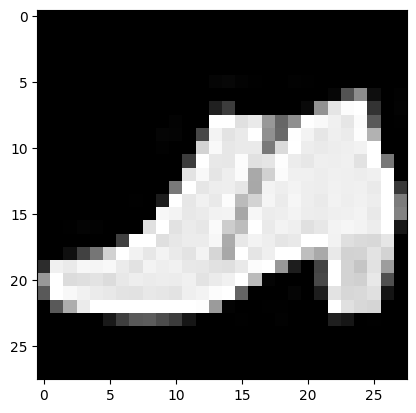

Label: 9
Feature batch shape: torch.Size([512, 1, 28, 28])
Labels batch shape: torch.Size([512])


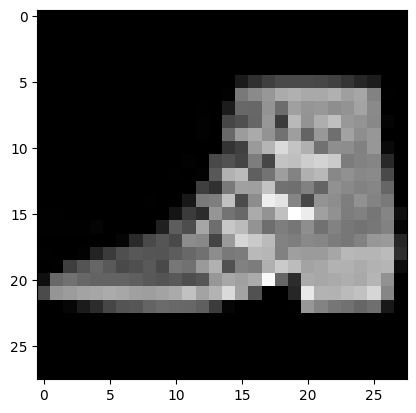

Label: 9
Feature batch shape: torch.Size([512, 1, 28, 28])
Labels batch shape: torch.Size([512])


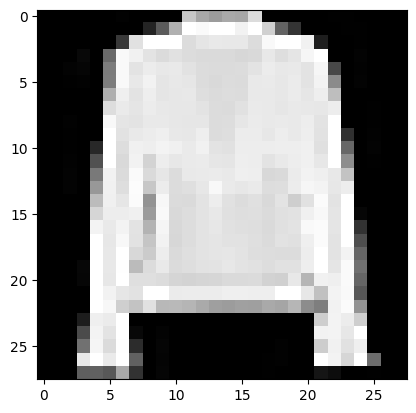

Label: 6
Feature batch shape: torch.Size([512, 1, 28, 28])
Labels batch shape: torch.Size([512])


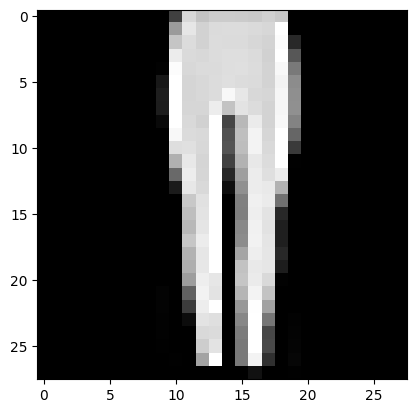

Label: 1
Feature batch shape: torch.Size([512, 1, 28, 28])
Labels batch shape: torch.Size([512])


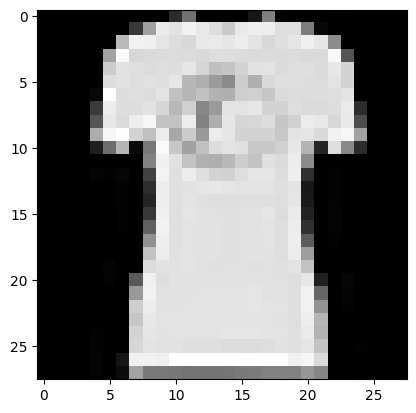

Label: 0
Feature batch shape: torch.Size([512, 1, 28, 28])
Labels batch shape: torch.Size([512])


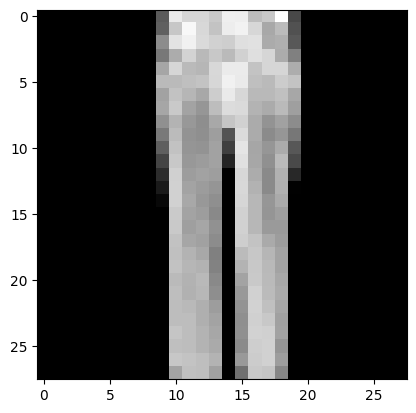

Label: 1
Feature batch shape: torch.Size([512, 1, 28, 28])
Labels batch shape: torch.Size([512])


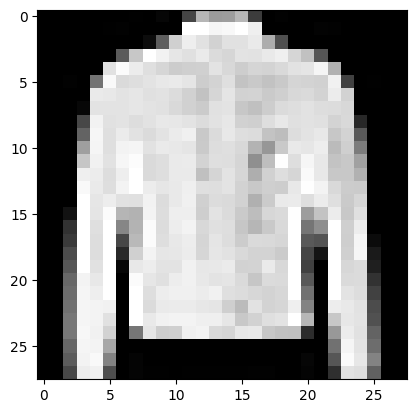

Label: 4
Feature batch shape: torch.Size([512, 1, 28, 28])
Labels batch shape: torch.Size([512])


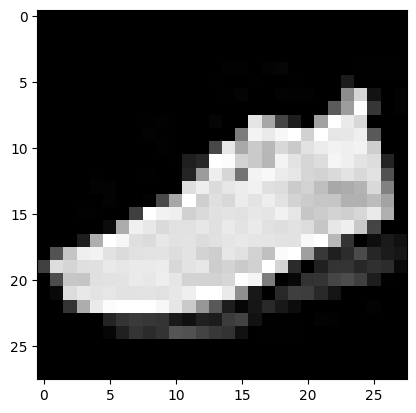

Label: 7
Feature batch shape: torch.Size([512, 1, 28, 28])
Labels batch shape: torch.Size([512])


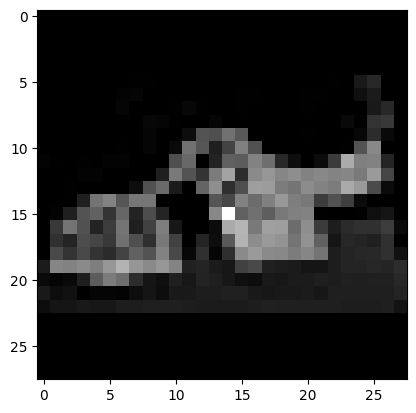

Label: 5
Feature batch shape: torch.Size([512, 1, 28, 28])
Labels batch shape: torch.Size([512])


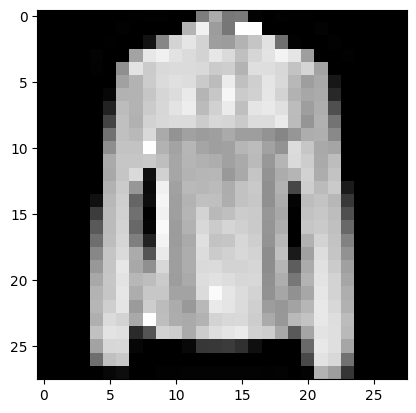

Label: 6
Feature batch shape: torch.Size([512, 1, 28, 28])
Labels batch shape: torch.Size([512])


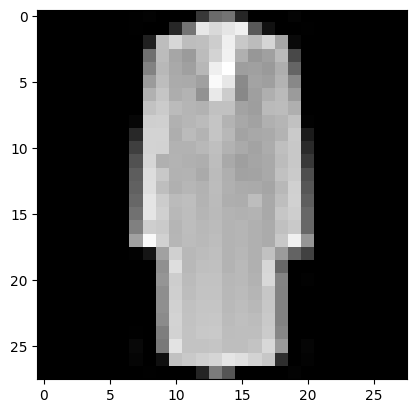

Label: 4
Feature batch shape: torch.Size([512, 1, 28, 28])
Labels batch shape: torch.Size([512])


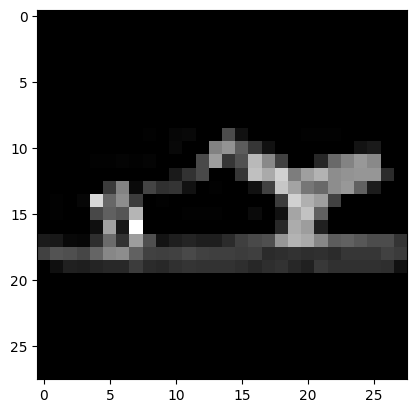

Label: 5
Feature batch shape: torch.Size([512, 1, 28, 28])
Labels batch shape: torch.Size([512])


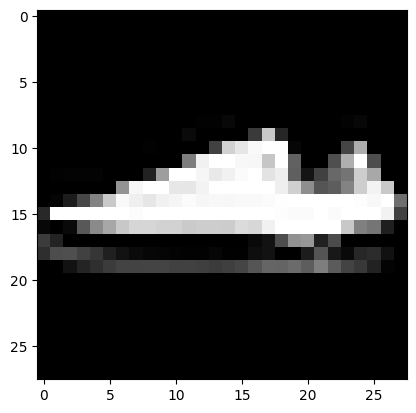

Label: 7
Feature batch shape: torch.Size([512, 1, 28, 28])
Labels batch shape: torch.Size([512])


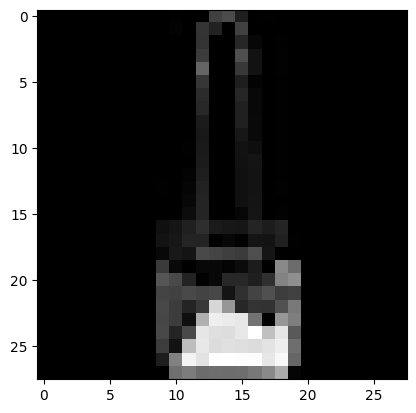

Label: 8


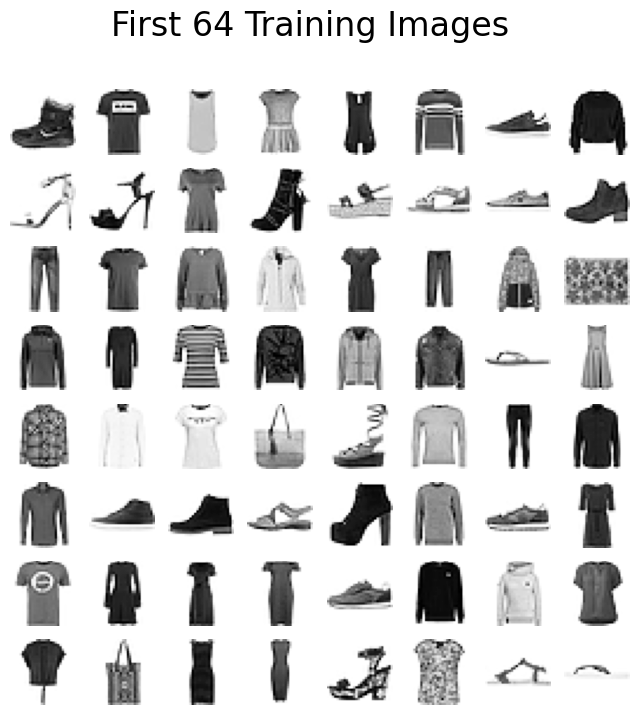

In [3]:
# Use the following code to load and normalize the dataset for training and testing
# It will downlad the dataset into data subfolder (change to your data folder name)
train_dataset = torchvision.datasets.FashionMNIST('data/', train=True, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.1307,), (0.3081,))
                             ]))

test_dataset = torchvision.datasets.FashionMNIST('data/', train=False, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.1307,), (0.3081,))
                             ]))


# Use the following code to create a validation set of 10%
train_indices, val_indices, _, _ = train_test_split(
    range(len(train_dataset)),
    train_dataset.targets,
    stratify=train_dataset.targets,
    test_size=0.1,
)

# Generate training and validation subsets based on indices
train_split = Subset(train_dataset, train_indices)
val_split = Subset(train_dataset, val_indices)


# set batches sizes
train_batch_size = 512 #Define train batch size
test_batch_size  = 256 #Define test batch size (can be larger than train batch size)


# Define dataloader objects that help to iterate over batches and samples for
# training, validation and testing
train_batches = DataLoader(train_split, batch_size=train_batch_size, shuffle=True)
val_batches = DataLoader(val_split, batch_size=train_batch_size, shuffle=True)
test_batches = DataLoader(test_dataset, batch_size=test_batch_size, shuffle=True)
                                           
num_train_batches=len(train_batches)
num_val_batches=len(val_batches)
num_test_batches=len(test_batches)


print(num_train_batches)
print(num_val_batches)
print(num_test_batches)


#Sample code to visulaize the first sample in first 16 batches 

batch_num = 0
for train_features, train_labels in train_batches:
    
    if batch_num == 16:
        break    # break here
    
    batch_num = batch_num +1
    print(f"Feature batch shape: {train_features.size()}")
    print(f"Labels batch shape: {train_labels.size()}")
    
    img = train_features[0].squeeze()
    label = train_labels[0]
    plt.imshow(img, cmap="gray")
    plt.show()
    print(f"Label: {label}")



# Sample code to plot N^2 images from the dataset
def plot_images(XX, N, title):
    fig, ax = plt.subplots(N, N, figsize=(8, 8))
    
    for i in range(N):
        for j in range(N):
            ax[i,j].imshow(XX[(N)*i+j], cmap="Greys")
            ax[i,j].axis("off")
    fig.suptitle(title, fontsize=24)

plot_images(train_dataset.data[:64], 8, "First 64 Training Images" )


In [4]:
#Define your (As Cool As It Gets) Fully Connected Neural Network 
class ACAIGFCN(nn.Module):
    #Initialize model layers, add additional arguments to adjust
    def __init__(self, input_dim, output_dim, hidden_dims=[256, 128, 64], dropout_rate=0.5):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, dim))
            layers.append(nn.BatchNorm1d(dim)) 
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate)) 
            prev_dim = dim
        layers.append(nn.Linear(prev_dim, output_dim))
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)

In [5]:
# Initialize neural network model with input, output and hidden layer dimensions
model = ACAIGFCN(input_dim = 784, output_dim = 10, hidden_dims=[256, 128, 64], dropout_rate=0.5) #... add more parameters
                
# Define the learning rate and epochs number
learning_rate = 0.01
epochs = 50


train_loss_list = np.zeros((epochs,))
validation_accuracy_list = np.zeros((epochs,))

# Define loss function  and optimizer
loss_func = nn.CrossEntropyLoss()# Use Cross Entropy loss from torch.nn 
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum = 0.9)# Use optimizers from torch.optim


start_time = time.perf_counter()

# Iterate over epochs, batches with progress bar and train+ validate the ACAIGFCN
# Track the loss and validation accuracy
for epoch in tqdm.trange(epochs):
    model.train()
    train_loss = 0.0
    # ACAIGFCN Training 
    for train_features, train_labels in train_batches:
        # Set model into training mode
        
        
        # Reshape images into a vector
        train_features = train_features.reshape(-1, 28*28)
        optimizer.zero_grad()
        outputs = model(train_features)
        loss = loss_func(outputs, train_labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        # Reset gradients, Calculate training loss on model 
        # Perfrom optimization, back propagation
 
    # Record loss for the epoch
    train_loss_list[epoch] = train_loss / len(train_batches)
    
    
    model.eval()
    val_acc = 0.0
    with torch.no_grad():      
    # ACAIGFCN Validation
    
        # Telling PyTorch we aren't passing inputs to network for training purpose
        for val_features, val_labels in val_batches:
        
             # Reshape validation images into a vector
            val_features = val_features.reshape(-1, 28*28)
          
            outputs = model(val_features)
            preds = torch.argmax(outputs, dim=1)
            val_acc += (preds == val_labels).sum().item() / len(val_labels)
            validation_accuracy_list[epoch] = val_acc / len(val_batches)
            # Compute validation outputs (targets) 
            # and compute accuracy 
            
    # Record accuracy for the epoch; print training loss, validation accuracy
    print("Epoch: "+ str(epoch) +"; Validation Accuracy:" + str(val_acc/len(val_batches)*100) + '%')

end_time = time.perf_counter()
elapsed_time = end_time - start_time

  2%|█▋                                                                                 | 1/50 [00:18<15:10, 18.59s/it]

Epoch: 0; Validation Accuracy:78.06484941123189%


  4%|███▎                                                                               | 2/50 [00:44<18:30, 23.14s/it]

Epoch: 1; Validation Accuracy:82.1862262228261%


  6%|████▉                                                                              | 3/50 [01:15<20:43, 26.45s/it]

...

Epoch: 47; Validation Accuracy:89.29248754528986%


 98%|████████████████████████████████████████████████████████████████████████████████▎ | 49/50 [23:40<00:28, 28.68s/it]

Epoch: 48; Validation Accuracy:89.34626924818842%


100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [24:08<00:00, 28.98s/it]

Epoch: 49; Validation Accuracy:89.35263813405797%


training time: 1448.804156 s


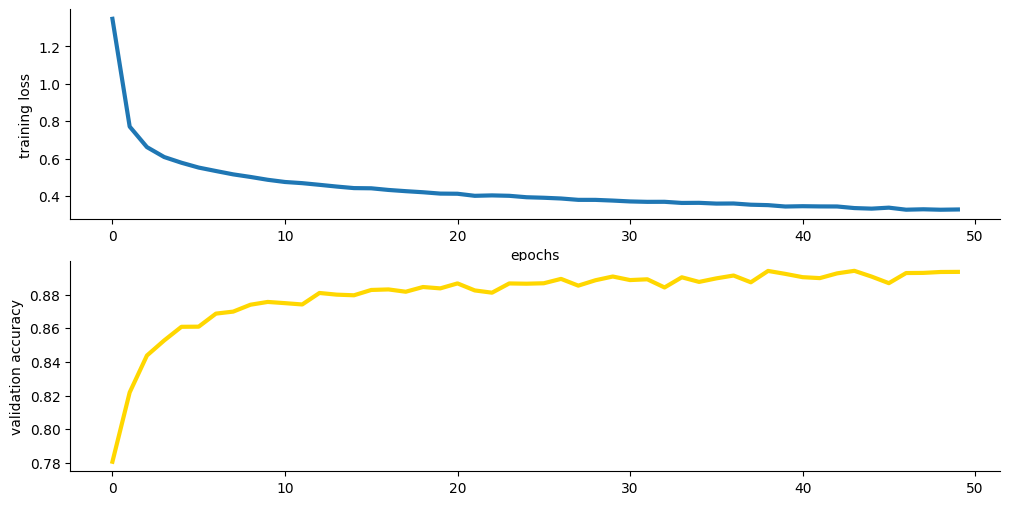

In [6]:
# Plot training loss and validation accuracy throughout the training epochs
# Plot training loss and validation accuracy throughout the training epochs
print(f"training time: {elapsed_time:.6f} s")

plt.figure(figsize = (12, 6))

plt.subplot(2, 1, 1)
plt.plot(train_loss_list, linewidth = 3)
plt.ylabel("training loss")
plt.xlabel("epochs")

plt.subplot(2, 1, 2)
plt.plot(validation_accuracy_list, linewidth = 3, color = 'gold')
plt.ylabel("validation accuracy")
sns.despine()

In [7]:
#Calculate accuracy on test set

# Telling PyTorch we aren't passing inputs to network for training purpose
model.eval()
test_correct = 0
test_total = len(test_dataset)
with torch.no_grad():
    
    for test_features, test_labels in test_batches:

        
        # Reshape test images into a vector
        test_features = test_features.reshape(-1, 28*28)
        outputs = model(test_features)
        preds = torch.argmax(outputs, dim=1)
        test_correct += (preds == test_labels).sum().item()
         # Compute validation outputs (targets) 
         # and compute accuracy 
    
    # Compute total (mean) accuracy
    # Report total (mean) accuracy, can also compute std based on batches
test_accuracy = test_correct / test_total
print(f"Test Accuracy: {test_accuracy:.2%}")

Test Accuracy: 88.51%


In [8]:
class ACAIGFCN(nn.Module):
    def __init__(
        self, 
        input_dim=784, 
        output_dim=10, 
        hidden_dims=[256, 128, 64], 
        use_dropout=True,
        dropout_rate=0.5,
        use_batchnorm=True,
        init_method='kaiming'
    ):
        super().__init__()
        layers = []
        dims = [input_dim] + hidden_dims + [output_dim]
        

        for i in range(len(dims)-1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            

            if use_batchnorm and i < len(dims)-2:
                layers.append(nn.BatchNorm1d(dims[i+1]))
            

            if i < len(dims)-2:
                layers.append(nn.ReLU())
                if use_dropout:
                    layers.append(nn.Dropout(dropout_rate))
        
        self.net = nn.Sequential(*layers)
        

        self._initialize_weights(init_method)

    def _initialize_weights(self, method):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                if method == 'xavier':
                    nn.init.xavier_normal_(layer.weight)
                elif method == 'kaiming':
                    nn.init.kaiming_normal_(layer.weight, mode='fan_in', nonlinearity='relu')
                elif method == 'normal':
                    nn.init.normal_(layer.weight, -0.1, 0.1)
                if layer.bias is not None:
                    nn.init.zeros_(layer.bias)
    
    def forward(self, x):
        return self.net(x)
    

In [9]:
def get_optimizer(model, optimizer_name, lr):
    if optimizer_name == 'sgd':
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimizer_name == 'adam':
        return torch.optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.999))
    elif optimizer_name == 'rmsprop':
        return torch.optim.RMSprop(model.parameters(), lr=lr, alpha=0.99)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")

In [10]:
def train_and_evaluate(
    train_batches, 
    val_batches,
    test_batches,
    hidden_dims=[256, 128, 64],
    optimizer_name='adam',
    lr=0.01,
    epochs=50,
    use_dropout=True,
    dropout_rate=0.5,
    use_batchnorm=True,
    init_method='kaiming'
):

    model = ACAIGFCN(
        hidden_dims=hidden_dims,
        use_dropout=use_dropout,
        dropout_rate=dropout_rate,
        use_batchnorm=use_batchnorm,
        init_method=init_method
    )
    

    criterion = nn.CrossEntropyLoss()
    optimizer = get_optimizer(model, optimizer_name, lr)
    

    train_losses = []
    val_accuracies = []
    

    for epoch in range(epochs):

        model.train()
        epoch_loss = 0.0
        for X, y in train_batches:
            X = X.view(X.size(0), -1) 
            optimizer.zero_grad()
            outputs = model(X)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        avg_loss = epoch_loss / len(train_batches)
        train_losses.append(avg_loss)
        

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for X, y in val_batches:
                X = X.view(X.size(0), -1)
                outputs = model(X)
                _, predicted = torch.max(outputs.data, 1)
                total += y.size(0)
                correct += (predicted == y).sum().item()
        val_acc = 100 * correct / total
        val_accuracies.append(val_acc)
        
        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {avg_loss:.4f} | "
              f"Val Acc: {val_acc:.2f}%")
    

    test_acc = evaluate_model(model, test_batches)
    return train_losses, val_accuracies, test_acc

def evaluate_model(model, test_batches):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X, y in test_batches:
            X = X.view(X.size(0), -1)
            outputs = model(X)
            _, predicted = torch.max(outputs.data, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()
    return 100 * correct / total

In [14]:
configs = [
    {'optimizer_name': 'sgd', 'lr': 0.01},
    {'optimizer_name': 'adam', 'lr': 0.01},
    {'optimizer_name': 'rmsprop', 'lr': 0.01}
]

results = {}
for config in configs:
    print(f"Training with {config}")
    start_time = time.perf_counter()
    train_loss, val_acc, test_acc = train_and_evaluate(
        train_batches,
        val_batches,
        test_batches,
        optimizer_name=config['optimizer_name'],
        lr=config['lr']
    )
    results[config['optimizer_name']] = {
        'train_loss': train_loss,
        'val_acc': val_acc,
        'test_acc':test_acc
    }
    end_time = time.perf_counter()
    elapsed_time = end_time - start_time
    print(f"{config['optimizer_name']}training time: {elapsed_time:.6f} s")

Training with {'optimizer_name': 'sgd', 'lr': 0.01}
Epoch 1/50 | Train Loss: 1.7005 | Val Acc: 73.25%
Epoch 2/50 | Train Loss: 1.0264 | Val Acc: 76.53%
Epoch 3/50 | Train Loss: 0.8811 | Val Acc: 77.92%
Epoch 4/50 | Train Loss: 0.7981 | Val Acc: 79.40%
Epoch 5/50 | Train Loss: 0.7453 | Val Acc: 80.85%
Epoch 6/50 | Train Loss: 0.7110 | Val Acc: 82.07%
Epoch 7/50 | Train Loss: 0.6853 | Val Acc: 82.87%
Epoch 8/50 | Train Loss: 0.6650 | Val Acc: 83.32%
Epoch 9/50 | Train Loss: 0.6422 | Val Acc: 83.87%
Epoch 10/50 | Train Loss: 0.6243 | Val Acc: 84.03%
Epoch 11/50 | Train Loss: 0.6161 | Val Acc: 84.33%
Epoch 12/50 | Train Loss: 0.6034 | Val Acc: 84.37%
Epoch 13/50 | Train Loss: 0.5900 | Val Acc: 84.90%
Epoch 14/50 | Train Loss: 0.5778 | Val Acc: 85.27%
Epoch 15/50 | Train Loss: 0.5646 | Val Acc: 85.28%
Epoch 16/50 | Train Loss: 0.5589 | Val Acc: 85.38%
Epoch 17/50 | Train Loss: 0.5521 | Val Acc: 85.77%
Epoch 18/50 | Train Loss: 0.5434 | Val Acc: 85.82%
Epoch 19/50 | Train Loss: 0.5393 | Val 

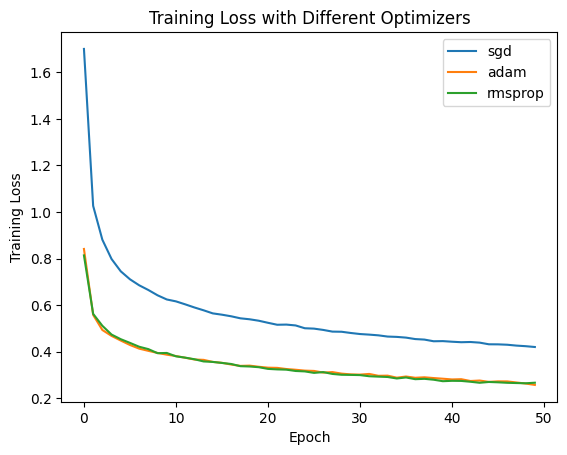

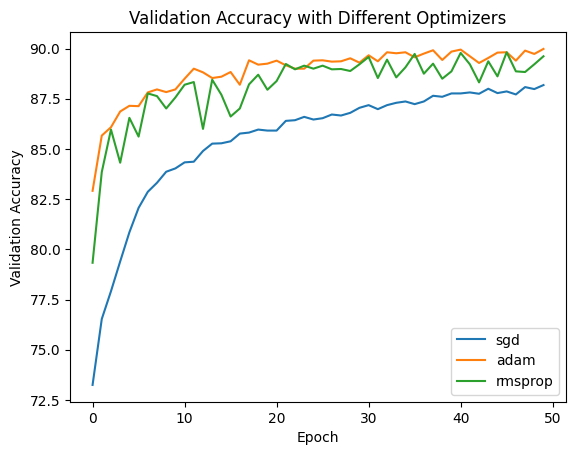

sgd test_accuracy: 87.02
adam test_accuracy: 89.23
rmsprop test_accuracy: 88.69


In [15]:
for opt_name, data in results.items():
    plt.plot(data['train_loss'], label=f"{opt_name}")
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.legend()
plt.title('Training Loss with Different Optimizers')
plt.show()

for opt_name, data in results.items():
    plt.plot(data['val_acc'], label=f"{opt_name}")
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.title('Validation Accuracy with Different Optimizers')
plt.show()

for opt_name, data in results.items():
    print(f"{opt_name} test_accuracy:",data['test_acc'])

In [11]:
configs = [
    {'optimizer_name': 'sgd', 'lr': 0.01},
    {'optimizer_name': 'sgd', 'lr': 0.001},
    {'optimizer_name': 'rmsprop', 'lr': 0.1}
]

results = {}
for config in configs:
    print(f"Training with {config}")
    start_time = time.perf_counter()
    train_loss, val_acc, test_acc = train_and_evaluate(
        train_batches,
        val_batches,
        test_batches,
        optimizer_name=config['optimizer_name'],
        lr=config['lr']
    )
    results[config['lr']] = {
        'train_loss': train_loss,
        'val_acc': val_acc,
        'test_acc':test_acc
    }
    end_time = time.perf_counter()
    elapsed_time = end_time - start_time
    print(f"{config['lr']}training time: {elapsed_time:.6f} s")

Training with {'optimizer_name': 'sgd', 'lr': 0.01}
Epoch 1/50 | Train Loss: 1.6893 | Val Acc: 74.27%
Epoch 2/50 | Train Loss: 1.0384 | Val Acc: 77.25%
Epoch 3/50 | Train Loss: 0.8886 | Val Acc: 79.42%
Epoch 4/50 | Train Loss: 0.8012 | Val Acc: 80.67%
Epoch 5/50 | Train Loss: 0.7587 | Val Acc: 82.02%
Epoch 6/50 | Train Loss: 0.7171 | Val Acc: 82.80%
Epoch 7/50 | Train Loss: 0.6865 | Val Acc: 83.48%
Epoch 8/50 | Train Loss: 0.6624 | Val Acc: 83.80%
Epoch 9/50 | Train Loss: 0.6426 | Val Acc: 84.40%
Epoch 10/50 | Train Loss: 0.6259 | Val Acc: 84.75%
Epoch 11/50 | Train Loss: 0.6100 | Val Acc: 85.12%
Epoch 12/50 | Train Loss: 0.5938 | Val Acc: 85.12%
Epoch 13/50 | Train Loss: 0.5869 | Val Acc: 85.50%
Epoch 14/50 | Train Loss: 0.5789 | Val Acc: 85.77%
Epoch 15/50 | Train Loss: 0.5660 | Val Acc: 85.93%
Epoch 16/50 | Train Loss: 0.5598 | Val Acc: 85.98%
Epoch 17/50 | Train Loss: 0.5510 | Val Acc: 86.10%
Epoch 18/50 | Train Loss: 0.5426 | Val Acc: 86.25%
Epoch 19/50 | Train Loss: 0.5372 | Val 

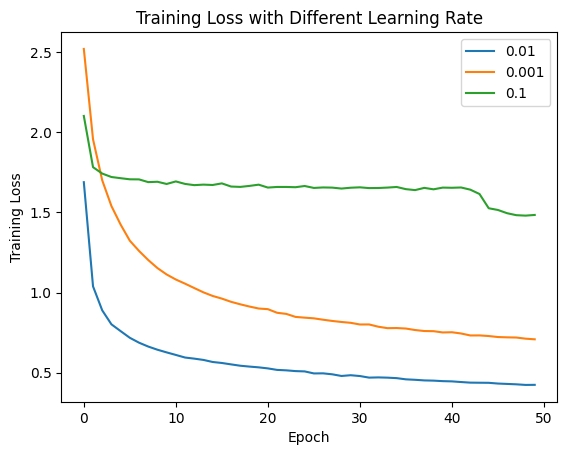

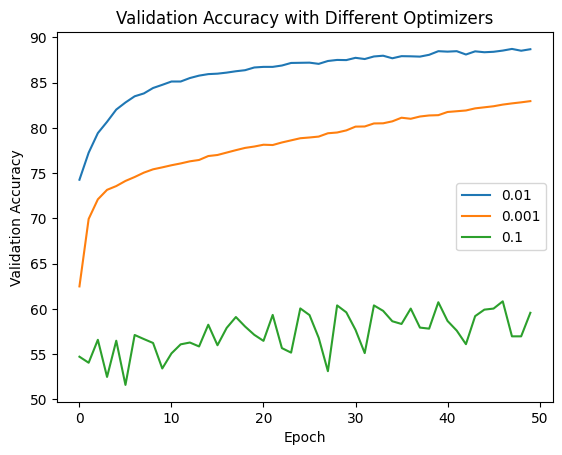

0.1 test_accuracy: 87.24
0.1 test_accuracy: 81.38
0.1 test_accuracy: 58.77


In [12]:
for lr, data in results.items():
    plt.plot(data['train_loss'], label=f"{lr}")
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.legend()
plt.title('Training Loss with Different Learning Rate')
plt.show()

for lr, data in results.items():
    plt.plot(data['val_acc'], label=f"{lr}")
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.title('Validation Accuracy with Different Optimizers')
plt.show()

for opt_name, data in results.items():
    print(f"{lr} test_accuracy:",data['test_acc'])

Epoch 1/50 | Train Loss: 0.8516 | Val Acc: 82.02%
Epoch 2/50 | Train Loss: 0.5686 | Val Acc: 85.07%
Epoch 3/50 | Train Loss: 0.5112 | Val Acc: 85.52%
Epoch 4/50 | Train Loss: 0.4715 | Val Acc: 86.12%
Epoch 5/50 | Train Loss: 0.4537 | Val Acc: 87.20%
Epoch 6/50 | Train Loss: 0.4312 | Val Acc: 87.45%
Epoch 7/50 | Train Loss: 0.4242 | Val Acc: 87.28%
Epoch 8/50 | Train Loss: 0.4114 | Val Acc: 88.10%
Epoch 9/50 | Train Loss: 0.4025 | Val Acc: 88.82%
Epoch 10/50 | Train Loss: 0.3898 | Val Acc: 88.43%
Epoch 11/50 | Train Loss: 0.3833 | Val Acc: 88.45%
Epoch 12/50 | Train Loss: 0.3727 | Val Acc: 88.72%
Epoch 13/50 | Train Loss: 0.3663 | Val Acc: 88.22%
Epoch 14/50 | Train Loss: 0.3674 | Val Acc: 88.90%
Epoch 15/50 | Train Loss: 0.3579 | Val Acc: 88.58%
Epoch 16/50 | Train Loss: 0.3495 | Val Acc: 88.80%
Epoch 17/50 | Train Loss: 0.3460 | Val Acc: 88.83%
Epoch 18/50 | Train Loss: 0.3440 | Val Acc: 89.07%
Epoch 19/50 | Train Loss: 0.3433 | Val Acc: 89.67%
Epoch 20/50 | Train Loss: 0.3375 | Val A

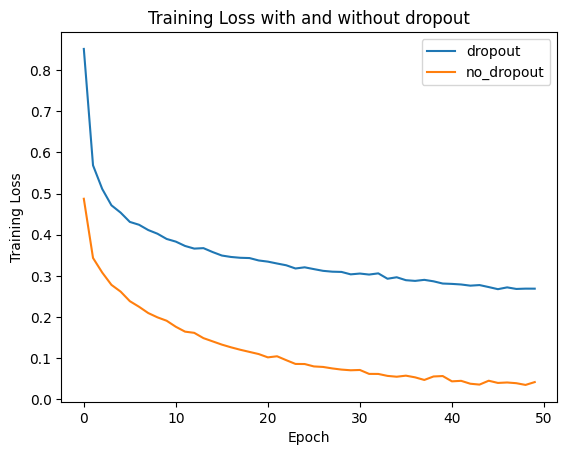

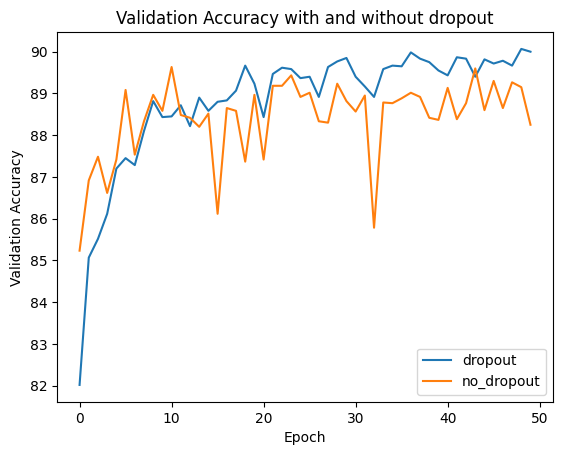

In [16]:
train_loss_dropout, val_acc_dropout, test_acc_dropout = train_and_evaluate(
    train_batches,
    val_batches,
    test_batches,
    use_dropout=True,
    dropout_rate=0.5
)


train_loss_no_dropout, val_acc_no_dropout, test_acc_no_dropout= train_and_evaluate(
    train_batches,
    val_batches,
    test_batches,
    use_dropout=False
)

plt.plot(train_loss_dropout, label=f"dropout")
plt.plot(train_loss_no_dropout, label=f"no_dropout")
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.legend()
plt.title('Training Loss with and without dropout')
plt.show()

plt.plot(val_acc_dropout, label=f"dropout")
plt.plot(val_acc_no_dropout, label=f"no_dropout")
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.title('Validation Accuracy with and without dropout')
plt.show()

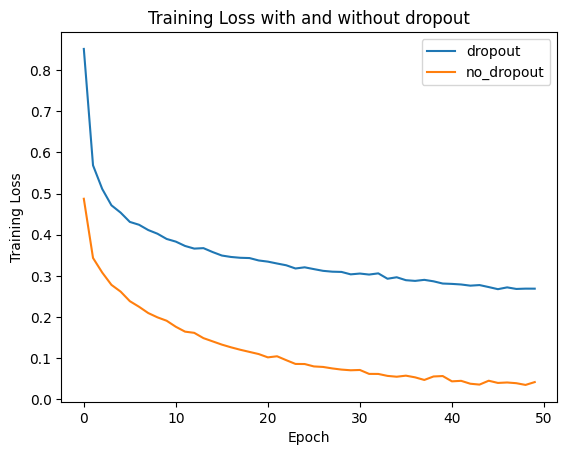

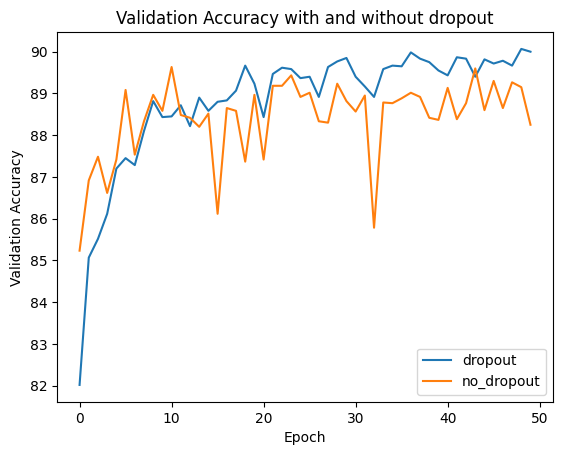

test_accuracy with dropout: 88.99
test_accuracy without dropout: 87.99


In [17]:
plt.plot(train_loss_dropout, label=f"dropout")
plt.plot(train_loss_no_dropout, label=f"no_dropout")
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.legend()
plt.title('Training Loss with and without dropout')
plt.show()

plt.plot(val_acc_dropout, label=f"dropout")
plt.plot(val_acc_no_dropout, label=f"no_dropout")
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.title('Validation Accuracy with and without dropout')
plt.show()
print(f"test_accuracy with dropout:",test_acc_dropout)
print(f"test_accuracy without dropout:",test_acc_no_dropout)

In [18]:
configs = [
    {'IC_name': 'kaiming'},
    {'IC_name': 'xavier'},
    {'IC_name': 'normal'}
]

results = {}

for config in configs:
    start_time = time.perf_counter()
    print(f"Training with {config}")
    train_loss, val_acc, test_acc = train_and_evaluate(
        train_batches,
        val_batches,
        test_batches,
        init_method=config['IC_name'],
    )
    results[config['IC_name']] = {
        'train_loss': train_loss,
        'val_acc': val_acc,
        'test_acc':test_acc
    }
    end_time = time.perf_counter()
    elapsed_time = end_time - start_time
    print(f"{config['IC_name']}training time: {elapsed_time:.6f} s")

Training with {'IC_name': 'kaiming'}
Epoch 1/50 | Train Loss: 0.8364 | Val Acc: 83.23%
Epoch 2/50 | Train Loss: 0.5577 | Val Acc: 85.53%
Epoch 3/50 | Train Loss: 0.5018 | Val Acc: 85.97%
Epoch 4/50 | Train Loss: 0.4702 | Val Acc: 86.73%
Epoch 5/50 | Train Loss: 0.4487 | Val Acc: 87.07%
Epoch 6/50 | Train Loss: 0.4332 | Val Acc: 87.43%
Epoch 7/50 | Train Loss: 0.4190 | Val Acc: 87.33%
Epoch 8/50 | Train Loss: 0.4050 | Val Acc: 87.15%
Epoch 9/50 | Train Loss: 0.3971 | Val Acc: 88.50%
Epoch 10/50 | Train Loss: 0.3919 | Val Acc: 88.57%
Epoch 11/50 | Train Loss: 0.3850 | Val Acc: 88.47%
Epoch 12/50 | Train Loss: 0.3682 | Val Acc: 88.68%
Epoch 13/50 | Train Loss: 0.3691 | Val Acc: 88.95%
Epoch 14/50 | Train Loss: 0.3625 | Val Acc: 88.65%
Epoch 15/50 | Train Loss: 0.3559 | Val Acc: 89.03%
Epoch 16/50 | Train Loss: 0.3511 | Val Acc: 89.15%
Epoch 17/50 | Train Loss: 0.3434 | Val Acc: 89.00%
Epoch 18/50 | Train Loss: 0.3411 | Val Acc: 89.55%
Epoch 19/50 | Train Loss: 0.3370 | Val Acc: 89.07%
Epo

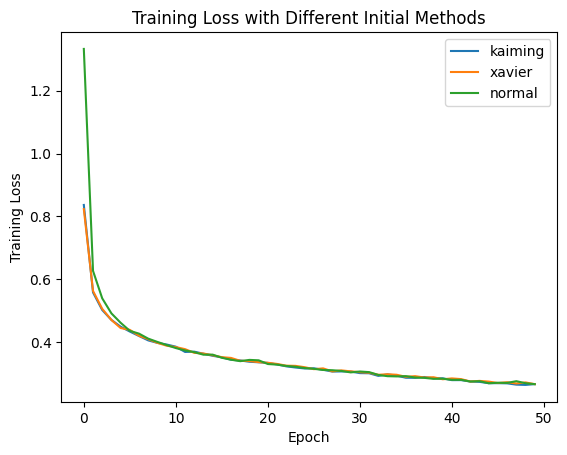

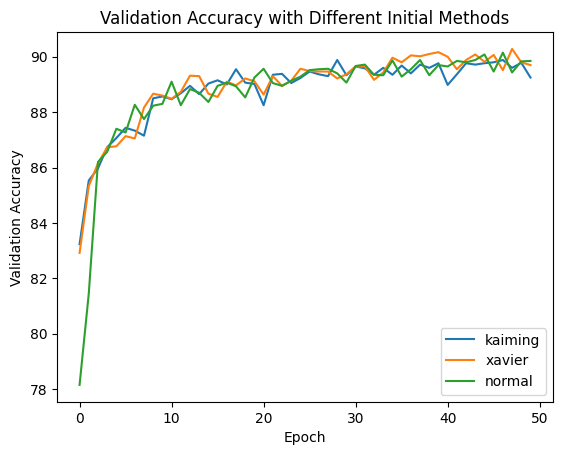

kaiming test_accuracy: 88.05
xavier test_accuracy: 89.03
normal test_accuracy: 88.99


In [19]:
for IC_name, data in results.items():
    plt.plot(data['train_loss'], label=f"{IC_name}")
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.legend()
plt.title('Training Loss with Different Initial Methods')
plt.show()

for IC_name, data in results.items():
    plt.plot(data['val_acc'], label=f"{IC_name}")
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.title('Validation Accuracy with Different Initial Methods')
plt.show()

for IC_name, data in results.items():
    print(f"{IC_name} test_accuracy:",data['test_acc'])

In [20]:
train_loss_bn, val_acc_bn, test_acc_bn = train_and_evaluate(train_batches, val_batches, test_batches, use_batchnorm=True)

train_loss_no_bn, val_acc_no_bn, test_acc_no_bn = train_and_evaluate(train_batches, val_batches, test_batches, use_batchnorm=False)

Epoch 1/50 | Train Loss: 0.8433 | Val Acc: 83.55%
Epoch 2/50 | Train Loss: 0.5606 | Val Acc: 84.88%
Epoch 3/50 | Train Loss: 0.5038 | Val Acc: 86.30%
Epoch 4/50 | Train Loss: 0.4699 | Val Acc: 86.65%
Epoch 5/50 | Train Loss: 0.4518 | Val Acc: 86.63%
Epoch 6/50 | Train Loss: 0.4352 | Val Acc: 86.45%
Epoch 7/50 | Train Loss: 0.4176 | Val Acc: 88.07%
Epoch 8/50 | Train Loss: 0.4055 | Val Acc: 87.93%
Epoch 9/50 | Train Loss: 0.3928 | Val Acc: 88.23%
Epoch 10/50 | Train Loss: 0.3913 | Val Acc: 88.45%
Epoch 11/50 | Train Loss: 0.3839 | Val Acc: 88.40%
Epoch 12/50 | Train Loss: 0.3721 | Val Acc: 88.37%
Epoch 13/50 | Train Loss: 0.3670 | Val Acc: 88.55%
Epoch 14/50 | Train Loss: 0.3598 | Val Acc: 88.70%
Epoch 15/50 | Train Loss: 0.3586 | Val Acc: 89.10%
Epoch 16/50 | Train Loss: 0.3513 | Val Acc: 89.42%
Epoch 17/50 | Train Loss: 0.3447 | Val Acc: 88.93%
Epoch 18/50 | Train Loss: 0.3420 | Val Acc: 89.17%
Epoch 19/50 | Train Loss: 0.3407 | Val Acc: 89.02%
Epoch 20/50 | Train Loss: 0.3334 | Val A

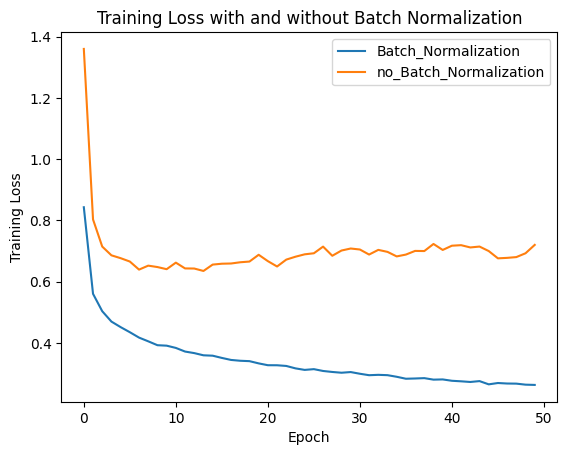

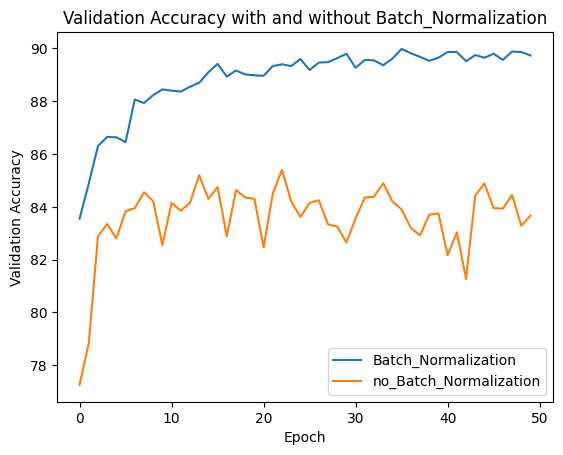

test_accuracy with batch normalization: 89.09
test_accuracy without batch normalization: 82.65


In [21]:
plt.plot(train_loss_bn, label=f"Batch_Normalization")
plt.plot(train_loss_no_bn, label=f"no_Batch_Normalization")
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.legend()
plt.title('Training Loss with and without Batch Normalization')
plt.show()

plt.plot(val_acc_bn, label=f"Batch_Normalization")
plt.plot(val_acc_no_bn, label=f"no_Batch_Normalization")
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.title('Validation Accuracy with and without Batch_Normalization')
plt.show()

print(f"test_accuracy with batch normalization:",test_acc_bn)
print(f"test_accuracy without batch normalization:",test_acc_no_bn)